In [89]:
import os
for dirname, _, filenames in os.walk('/Users/vibhasharma/Downloads/ncr_ride_bookings.csv'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [90]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


pd.set_option("display.max_columns", None)

In [91]:
df = pd.read_csv("/Users/vibhasharma/Downloads/ncr_ride_bookings.csv")
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [92]:
print("📌 Data Info:")
df.info()

print("\n📊 Summary Statistics:")
print(df.describe(include='all'))

print("\n🔍 Null Values per Column:")
print(df.isnull().sum())

📌 Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by C

## missing values


In [93]:
# Create binary flags from cancellation/incomplete columns
df['is_cancelled_customer'] = df['Cancelled Rides by Customer'].notnull()
df['is_cancelled_driver'] = df['Cancelled Rides by Driver'].notnull()
df['is_incomplete'] = df['Incomplete Rides'].notnull()

# Create a flag for missing ratings and booking values
df['missing_driver_rating'] = df['Driver Ratings'].isnull()
df['missing_customer_rating'] = df['Customer Rating'].isnull()
df['missing_booking_value'] = df['Booking Value'].isnull()
df['missing_payment_method'] = df['Payment Method'].isnull()

# Optional: Fill CTAT and VTAT with median if needed
df['Avg VTAT'] = df['Avg VTAT'].fillna(df['Avg VTAT'].median())
df['Avg CTAT'] = df['Avg CTAT'].fillna(df['Avg CTAT'].median())

# Optional: Fill Ratings and Booking Value with zeros if needed (for modeling)
# df['Driver Ratings'].fillna(0, inplace=True)
# df['Customer Rating'].fillna(0, inplace=True)
# df['Booking Value'].fillna(0, inplace=True)

# Check new flags
df[['is_cancelled_customer', 'is_cancelled_driver', 'is_incomplete',
    'missing_driver_rating', 'missing_customer_rating',
    'missing_booking_value', 'missing_payment_method']].sum()

is_cancelled_customer      10500
is_cancelled_driver        27000
is_incomplete               9000
missing_driver_rating      57000
missing_customer_rating    57000
missing_booking_value      48000
missing_payment_method     48000
dtype: int64

In [94]:
# Target variable
df['target_customer_cancelled'] = df['is_cancelled_customer'].astype(int)

# Quick target distribution check
df['target_customer_cancelled'].value_counts(normalize=True)

target_customer_cancelled
0    0.93
1    0.07
Name: proportion, dtype: float64

In [95]:
df[['Booking ID', "Booking Status"]].loc[df.duplicated(subset="Booking ID")]

,Booking ID,Booking Status
5522,"""CNR5071968""",No Driver Found
7762,"""CNR8512595""",Completed
9587,"""CNR1029172""",Completed
9726,"""CNR7132372""",Completed
10186,"""CNR7768664""",Completed
...,...,...
149785,"""CNR5629984""",Cancelled by Driver
149828,"""CNR9026484""",Cancelled by Driver
149928,"""CNR8005057""",Cancelled by Customer
149938,"""CNR8099403""",Cancelled by Customer


In [96]:
df[(df["Booking ID"] == '"CNR5071968"') & (df['Customer ID'] == '"CID7384045"')]

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,is_cancelled_customer,is_cancelled_driver,is_incomplete,missing_driver_rating,missing_customer_rating,missing_booking_value,missing_payment_method,target_customer_cancelled
317,2024-10-10,03:56:19,"""CNR5071968""",Completed,"""CID7384045""",Go Sedan,Panchsheel Park,Yamuna Bank,4.7,42.5,NaN,NaN,NaN,NaN,NaN,NaN,473.0,48.35,4.7,3.8,Cash,False,False,False,False,False,False,False,0


In [97]:
df['Booking Status'].unique()

array(['No Driver Found', 'Incomplete', 'Completed',
       'Cancelled by Driver', 'Cancelled by Customer'], dtype=object)

In [98]:
df.duplicated(subset=["Booking ID", "Customer ID"]).sum()

np.int64(0)

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 29 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           150000 non-null  float64
 9   Avg CTAT                           150000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [100]:
df.isna().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                                  0
Avg CTAT                                  0
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
is_cancelled_customer                     0
is_cancelled_driver             

In [101]:
pip install missingno

5680.80s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Note: you may need to restart the kernel to use updated packages.


In [102]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce').dt.time

# Combine Date and Time into a single datetime column
df['datetime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str), errors='coerce')

# Extract temporal features
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['weekday'] = df['datetime'].dt.dayofweek  # Monday=0, Sunday=6
df['is_weekend'] = df['weekday'].isin([5, 6])

# Check result
df[['datetime', 'hour', 'day', 'month', 'weekday', 'is_weekend']].head()

,datetime,hour,day,month,weekday,is_weekend
0,2024-03-23 12:29:38,12,23,3,5,True
1,2024-11-29 18:01:39,18,29,11,4,False
2,2024-08-23 08:56:10,8,23,8,4,False
3,2024-10-21 17:17:25,17,21,10,0,False
4,2024-09-16 22:08:00,22,16,9,0,False


In [103]:
# Create binary flags from cancellation/incomplete columns
df['is_cancelled_customer'] = df['Cancelled Rides by Customer'].notnull()
df['is_cancelled_driver'] = df['Cancelled Rides by Driver'].notnull()
df['is_incomplete'] = df['Incomplete Rides'].notnull()

# Create a flag for missing ratings and booking values
df['missing_driver_rating'] = df['Driver Ratings'].isnull()
df['missing_customer_rating'] = df['Customer Rating'].isnull()
df['missing_booking_value'] = df['Booking Value'].isnull()
df['missing_payment_method'] = df['Payment Method'].isnull()

# Optional: Fill CTAT and VTAT with median if needed
df['Avg VTAT'] = df['Avg VTAT'].fillna(df['Avg VTAT'].median())
df['Avg CTAT'] = df['Avg CTAT'].fillna(df['Avg CTAT'].median())

# Optional: Fill Ratings and Booking Value with zeros if needed (for modeling)
# df['Driver Ratings'].fillna(0, inplace=True)
# df['Customer Rating'].fillna(0, inplace=True)
# df['Booking Value'].fillna(0, inplace=True)

# Check new flags
df[['is_cancelled_customer', 'is_cancelled_driver', 'is_incomplete',
    'missing_driver_rating', 'missing_customer_rating',
    'missing_booking_value', 'missing_payment_method']].sum()

is_cancelled_customer      10500
is_cancelled_driver        27000
is_incomplete               9000
missing_driver_rating      57000
missing_customer_rating    57000
missing_booking_value      48000
missing_payment_method     48000
dtype: int64

In [104]:
# Target variable
df['target_customer_cancelled'] = df['is_cancelled_customer'].astype(int)

# Quick target distribution check
df['target_customer_cancelled'].value_counts(normalize=True)


target_customer_cancelled
0    0.93
1    0.07
Name: proportion, dtype: float64

<Axes: >

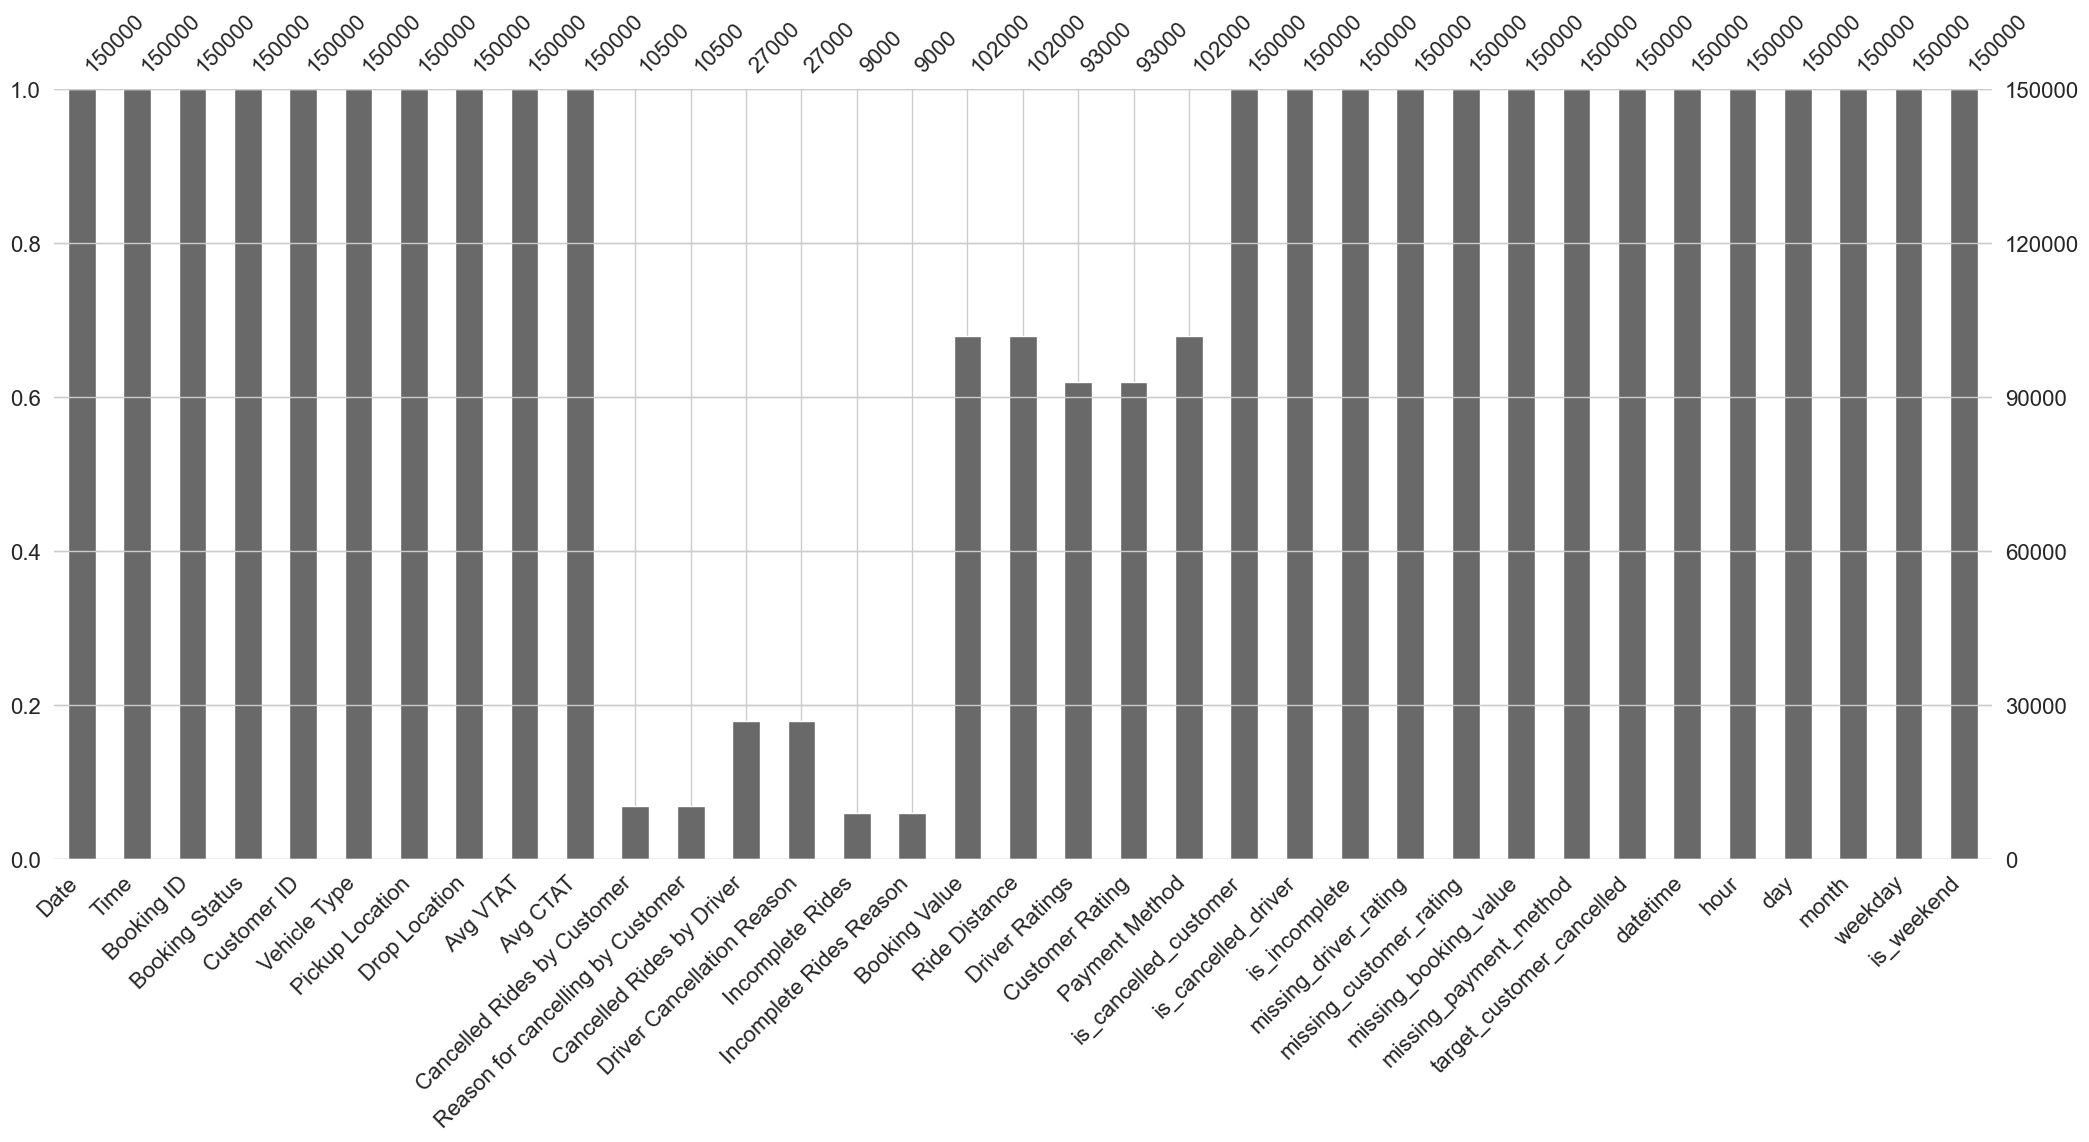

In [105]:
import missingno as msno
msno.bar(df)

<Axes: >

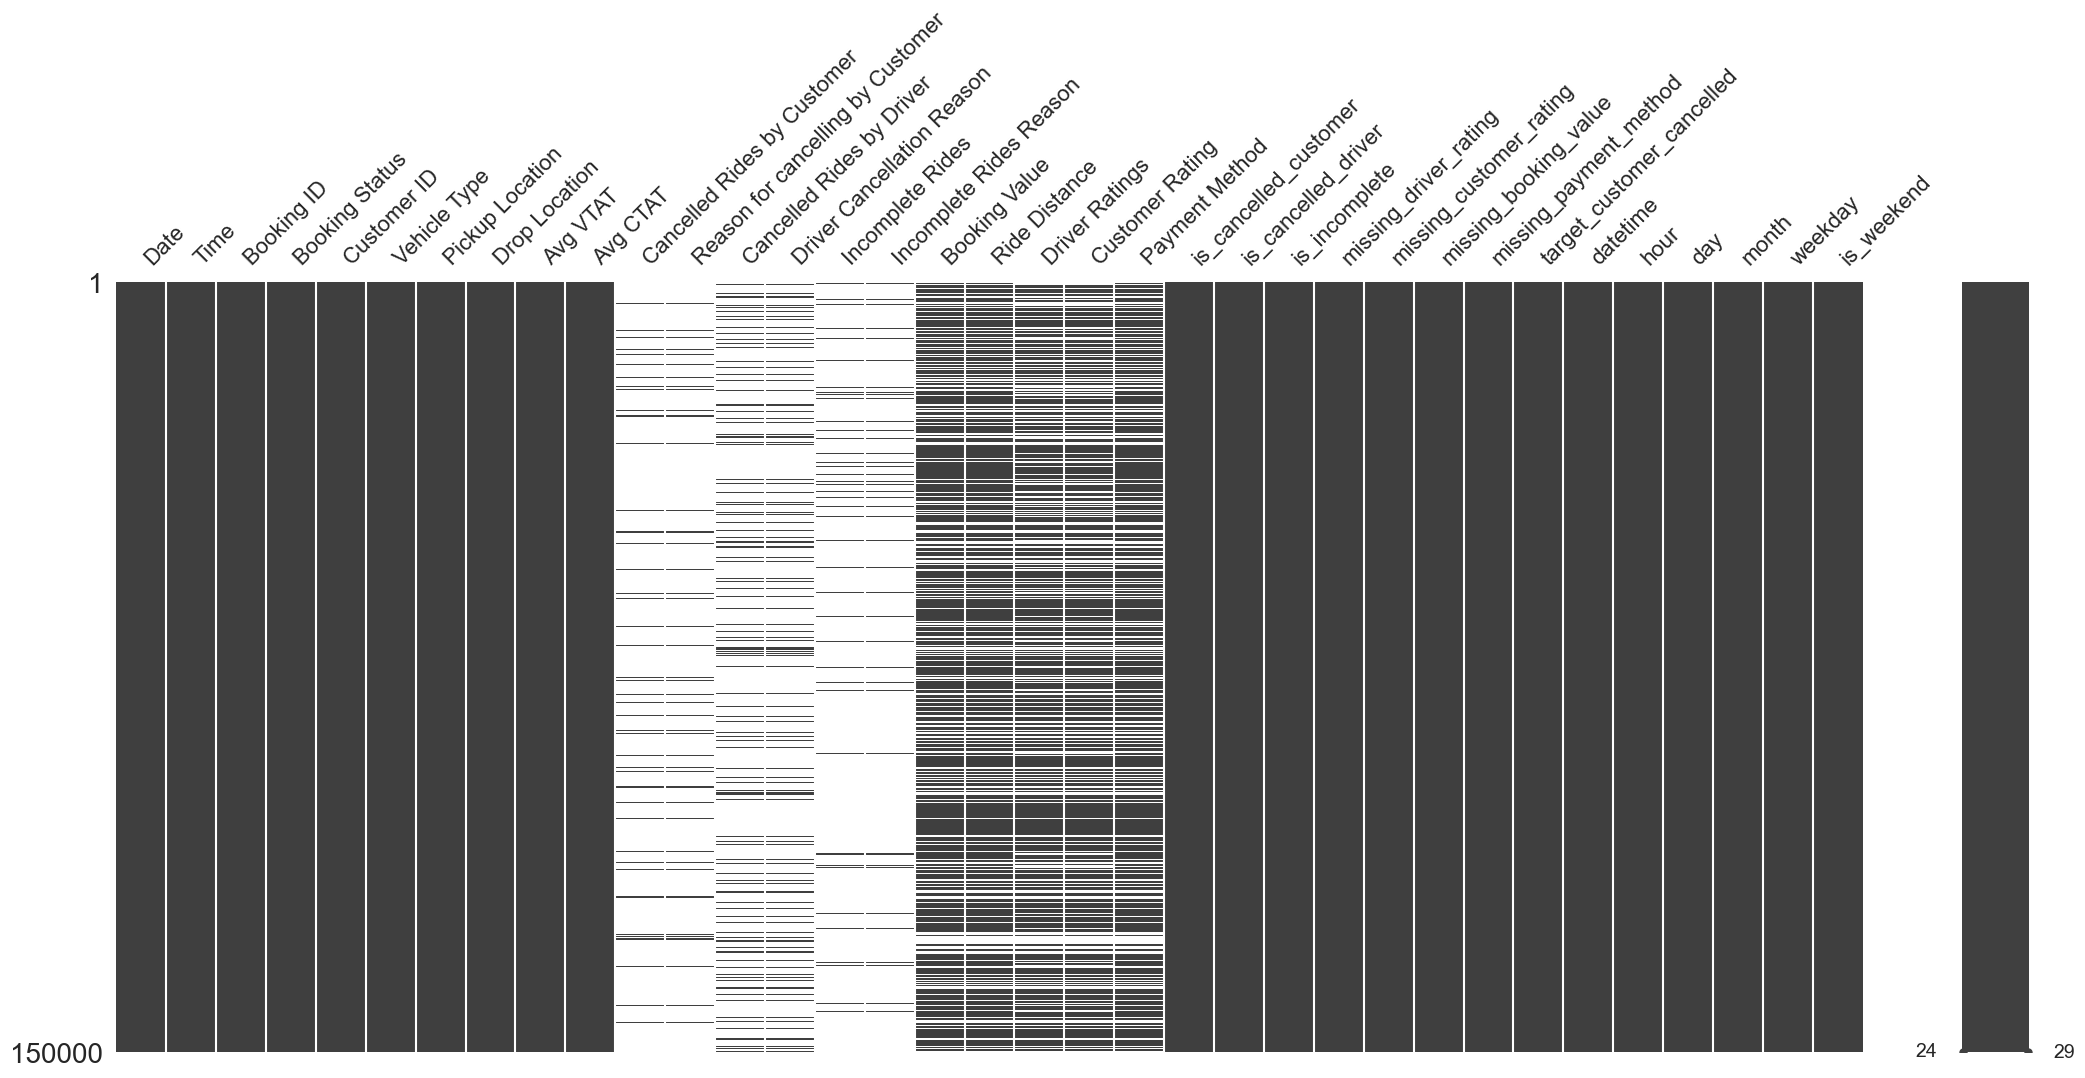

In [106]:
msno.matrix(df)

In [107]:
df['Booking Status'].unique()

array(['No Driver Found', 'Incomplete', 'Completed',
       'Cancelled by Driver', 'Cancelled by Customer'], dtype=object)

In [108]:
customer = df[['Booking Status', 'Cancelled Rides by Customer', 'Reason for cancelling by Customer']].dropna()
customer.head()

,Booking Status,Cancelled Rides by Customer,Reason for cancelling by Customer
18,Cancelled by Customer,1.0,Driver is not moving towards pickup location
39,Cancelled by Customer,1.0,Driver is not moving towards pickup location
46,Cancelled by Customer,1.0,Driver asked to cancel
62,Cancelled by Customer,1.0,Driver is not moving towards pickup location
78,Cancelled by Customer,1.0,Driver asked to cancel


In [109]:
customer2 = df[['Booking Status', 'Cancelled Rides by Customer', 'Reason for cancelling by Customer']].dropna()

In [110]:
print(150000 - 10500)

139500


In [111]:
customer2['Booking Status'].unique()

array(['Cancelled by Customer'], dtype=object)

In [112]:
customer2['Cancelled Rides by Customer'].unique()

array([1.])

In [113]:
customer2['Reason for cancelling by Customer'].unique()

array(['Driver is not moving towards pickup location',
       'Driver asked to cancel', 'AC is not working', 'Change of plans',
       'Wrong Address'], dtype=object)

In [114]:
driver = df[['Booking Status', 'Cancelled Rides by Driver', 'Driver Cancellation Reason']].dropna()
driver.head()

,Booking Status,Cancelled Rides by Driver,Driver Cancellation Reason
12,Cancelled by Driver,1.0,Personal & Car related issues
17,Cancelled by Driver,1.0,Customer related issue
19,Cancelled by Driver,1.0,Customer related issue
26,Cancelled by Driver,1.0,Personal & Car related issues
30,Cancelled by Driver,1.0,More than permitted people in there


In [115]:

driver.shape

(27000, 3)

In [116]:
print(150000-27000)

123000


In [117]:
for col in driver.columns:
    print(f"{col}: {driver[col].unique()}")

Booking Status: ['Cancelled by Driver']
Cancelled Rides by Driver: [1.]
Driver Cancellation Reason: ['Personal & Car related issues' 'Customer related issue'
 'More than permitted people in there' 'The customer was coughing/sick']


In [118]:
x = df[['Booking Status', 'Incomplete Rides', 'Incomplete Rides Reason']].dropna()
x.head()

,Booking Status,Incomplete Rides,Incomplete Rides Reason
1,Incomplete,1.0,Vehicle Breakdown
9,Incomplete,1.0,Other Issue
28,Incomplete,1.0,Vehicle Breakdown
42,Incomplete,1.0,Other Issue
47,Incomplete,1.0,Vehicle Breakdown


In [119]:
x.shape

(9000, 3)

In [120]:
print(150000-9000)

141000


In [121]:
for col in x.columns:
    print(f"{col}: {x[col].unique()}")

Booking Status: ['Incomplete']
Incomplete Rides: [1.]
Incomplete Rides Reason: ['Vehicle Breakdown' 'Other Issue' 'Customer Demand']


In [122]:
df['Reason'] = np.nan
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,is_cancelled_customer,is_cancelled_driver,is_incomplete,missing_driver_rating,missing_customer_rating,missing_booking_value,missing_payment_method,target_customer_cancelled,datetime,hour,day,month,weekday,is_weekend,Reason
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,8.3,28.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,True,True,True,True,0,2024-03-23 12:29:38,12,23,3,5,True,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,False,False,True,True,True,False,False,0,2024-11-29 18:01:39,18,29,11,4,False,NaN
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card,False,False,False,False,False,False,False,0,2024-08-23 08:56:10,8,23,8,4,False,NaN
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI,False,False,False,False,False,False,False,0,2024-10-21 17:17:25,17,21,10,0,False,NaN
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI,False,False,False,False,False,False,False,0,2024-09-16 22:08:00,22,16,9,0,False,NaN


In [123]:
df['Booking Status'].unique()

array(['No Driver Found', 'Incomplete', 'Completed',
       'Cancelled by Driver', 'Cancelled by Customer'], dtype=object)

In [124]:
df['Reason'][df['Booking Status'] == "No Driver Found"] = "No Driver Available"
df['Reason'].unique()

/var/folders/5q/xzz56pxn58q_j4hnpbtx1t5w0000gn/T/ipykernel_70234/1412075920.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Reason'][df['Booking Status'] == "No Driver Found"] = "No Driver Available"
/var/folders/5q/xzz56pxn58q_j4hnp

array(['No Driver Available', nan], dtype=object)

In [125]:
df['Reason'][df['Booking Status'] == "Completed"] = "Everything was fine"
df['Reason'].unique()

array(['No Driver Available', nan, 'Everything was fine'], dtype=object)

In [126]:
df.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method',
       'is_cancelled_customer', 'is_cancelled_driver', 'is_incomplete',
       'missing_driver_rating', 'missing_customer_rating',
       'missing_booking_value', 'missing_payment_method',
       'target_customer_cancelled', 'datetime', 'hour', 'day', 'month',
       'weekday', 'is_weekend', 'Reason'],
      dtype='object')

In [127]:
incomplete_resaons = df['Incomplete Rides Reason'][df['Booking Status'] == "Incomplete"].unique().tolist()

for reason in incomplete_resaons:
    df['Reason'][(df['Booking Status'] == "Incomplete") & (df['Incomplete Rides Reason'] == reason)] = reason

df['Reason'].unique()

array(['No Driver Available', 'Vehicle Breakdown', 'Everything was fine',
       'Other Issue', nan, 'Customer Demand'], dtype=object)

In [128]:
df['Booking Status'].unique()

array(['No Driver Found', 'Incomplete', 'Completed',
       'Cancelled by Driver', 'Cancelled by Customer'], dtype=object)

In [129]:
customer_reasons = df['Reason for cancelling by Customer'][df['Booking Status'] == "Cancelled by Customer"].unique().tolist()

for reason in customer_reasons:
    df['Reason'][(df['Booking Status'] == "Cancelled by Customer") & (df['Reason for cancelling by Customer'] == reason)] = reason

df['Reason'].unique()

array(['No Driver Available', 'Vehicle Breakdown', 'Everything was fine',
       'Other Issue', nan, 'Driver is not moving towards pickup location',
       'Driver asked to cancel', 'Customer Demand', 'AC is not working',
       'Change of plans', 'Wrong Address'], dtype=object)

In [130]:
driver_reasons = df['Driver Cancellation Reason'][df['Booking Status'] == "Cancelled by Driver"].unique().tolist()

for reason in driver_reasons:
    df['Reason'][(df['Booking Status'] == "Cancelled by Driver") & (df['Driver Cancellation Reason'] == reason)] = reason

df['Reason'].unique()

array(['No Driver Available', 'Vehicle Breakdown', 'Everything was fine',
       'Other Issue', 'Personal & Car related issues',
       'Customer related issue',
       'Driver is not moving towards pickup location',
       'More than permitted people in there', 'Driver asked to cancel',
       'Customer Demand', 'The customer was coughing/sick',
       'AC is not working', 'Change of plans', 'Wrong Address'],
      dtype=object)

In [131]:
df['Reason'].isna().sum()

np.int64(0)

In [132]:
df.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method',
       'is_cancelled_customer', 'is_cancelled_driver', 'is_incomplete',
       'missing_driver_rating', 'missing_customer_rating',
       'missing_booking_value', 'missing_payment_method',
       'target_customer_cancelled', 'datetime', 'hour', 'day', 'month',
       'weekday', 'is_weekend', 'Reason'],
      dtype='object')

In [133]:
df.drop(['Cancelled Rides by Customer', 'Reason for cancelling by Customer', 'Driver Cancellation Reason', 'Cancelled Rides by Driver', 'Incomplete Rides Reason', 'Incomplete Rides']
       , axis=1, inplace=True)

df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,is_cancelled_customer,is_cancelled_driver,is_incomplete,missing_driver_rating,missing_customer_rating,missing_booking_value,missing_payment_method,target_customer_cancelled,datetime,hour,day,month,weekday,is_weekend,Reason
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,8.3,28.8,NaN,NaN,NaN,NaN,NaN,False,False,False,True,True,True,True,0,2024-03-23 12:29:38,12,23,3,5,True,No Driver Available
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,237.0,5.73,NaN,NaN,UPI,False,False,True,True,True,False,False,0,2024-11-29 18:01:39,18,29,11,4,False,Vehicle Breakdown
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,627.0,13.58,4.9,4.9,Debit Card,False,False,False,False,False,False,False,0,2024-08-23 08:56:10,8,23,8,4,False,Everything was fine
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,416.0,34.02,4.6,5.0,UPI,False,False,False,False,False,False,False,0,2024-10-21 17:17:25,17,21,10,0,False,Everything was fine
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,737.0,48.21,4.1,4.3,UPI,False,False,False,False,False,False,False,0,2024-09-16 22:08:00,22,16,9,0,False,Everything was fine


In [134]:
df.isna().sum()

Date                             0
Time                             0
Booking ID                       0
Booking Status                   0
Customer ID                      0
Vehicle Type                     0
Pickup Location                  0
Drop Location                    0
Avg VTAT                         0
Avg CTAT                         0
Booking Value                48000
Ride Distance                48000
Driver Ratings               57000
Customer Rating              57000
Payment Method               48000
is_cancelled_customer            0
is_cancelled_driver              0
is_incomplete                    0
missing_driver_rating            0
missing_customer_rating          0
missing_booking_value            0
missing_payment_method           0
target_customer_cancelled        0
datetime                         0
hour                             0
day                              0
month                            0
weekday                          0
is_weekend          

In [135]:
df['Avg VTAT'].fillna(-1, inplace=True)
df['Avg CTAT'].fillna(-1, inplace=True)
df['Booking Value'].fillna(-1, inplace=True)
df['Ride Distance'].fillna(-1, inplace=True)
df['Driver Ratings'].fillna(-1, inplace=True)
df['Customer Rating'].fillna(-1, inplace=True)
df['Payment Method'].fillna("NO Payment", inplace=True)

/var/folders/5q/xzz56pxn58q_j4hnpbtx1t5w0000gn/T/ipykernel_70234/3062126359.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Avg VTAT'].fillna(-1, inplace=True)
/var/folders/5q/xzz56pxn58q_j4hnpbtx1t5w0000gn/T/ipykernel_70234/3062126359.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behave

In [136]:

df.isna().sum()

Date                         0
Time                         0
Booking ID                   0
Booking Status               0
Customer ID                  0
Vehicle Type                 0
Pickup Location              0
Drop Location                0
Avg VTAT                     0
Avg CTAT                     0
Booking Value                0
Ride Distance                0
Driver Ratings               0
Customer Rating              0
Payment Method               0
is_cancelled_customer        0
is_cancelled_driver          0
is_incomplete                0
missing_driver_rating        0
missing_customer_rating      0
missing_booking_value        0
missing_payment_method       0
target_customer_cancelled    0
datetime                     0
hour                         0
day                          0
month                        0
weekday                      0
is_weekend                   0
Reason                       0
dtype: int64

# EDA



In [137]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,is_cancelled_customer,is_cancelled_driver,is_incomplete,missing_driver_rating,missing_customer_rating,missing_booking_value,missing_payment_method,target_customer_cancelled,datetime,hour,day,month,weekday,is_weekend,Reason
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,8.3,28.8,-1.0,-1.00,-1.0,-1.0,NO Payment,False,False,False,True,True,True,True,0,2024-03-23 12:29:38,12,23,3,5,True,No Driver Available
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,237.0,5.73,-1.0,-1.0,UPI,False,False,True,True,True,False,False,0,2024-11-29 18:01:39,18,29,11,4,False,Vehicle Breakdown
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,627.0,13.58,4.9,4.9,Debit Card,False,False,False,False,False,False,False,0,2024-08-23 08:56:10,8,23,8,4,False,Everything was fine
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,416.0,34.02,4.6,5.0,UPI,False,False,False,False,False,False,False,0,2024-10-21 17:17:25,17,21,10,0,False,Everything was fine
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,737.0,48.21,4.1,4.3,UPI,False,False,False,False,False,False,False,0,2024-09-16 22:08:00,22,16,9,0,False,Everything was fine


In [138]:
status_percent = df['Booking Status'].value_counts(normalize=True) * 100
status_percent

Booking Status
Completed                62.0
Cancelled by Driver      18.0
No Driver Found           7.0
Cancelled by Customer     7.0
Incomplete                6.0
Name: proportion, dtype: float64

In [139]:
total = len(df)

completed = len(df[df['Booking Status'] == "Completed"])
cancelled = len(df[df['Booking Status'] != "Completed"])

print("Completion Rate:", round(completed/total*100,2), "%")
print("Cancellation Rate:", round(cancelled/total*100,2), "%")

Completion Rate: 62.0 %
Cancellation Rate: 38.0 %


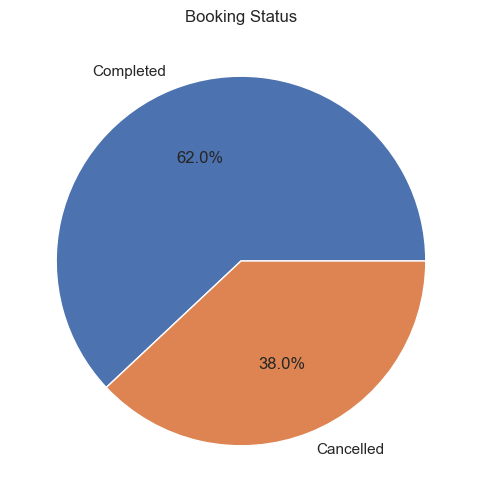

In [140]:
labels = ['Completed', 'Cancelled']
sizes = [completed, cancelled]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("Booking Status")
plt.show()

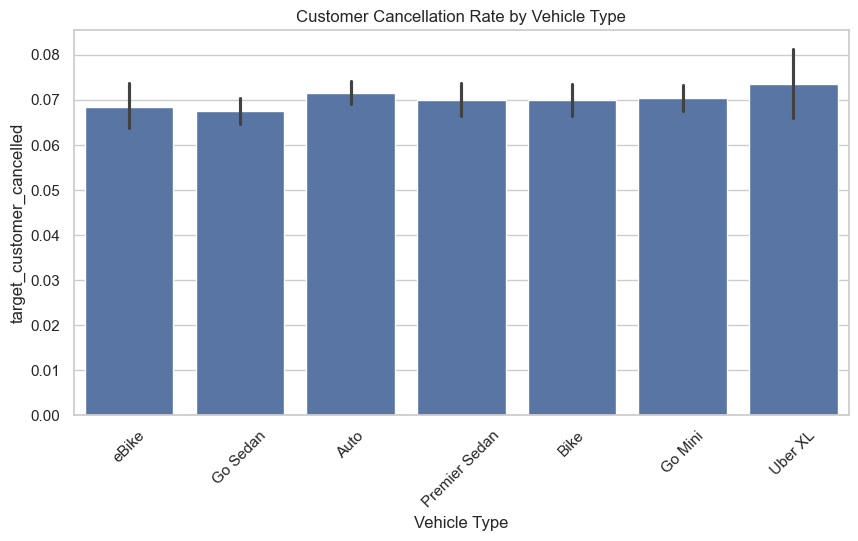

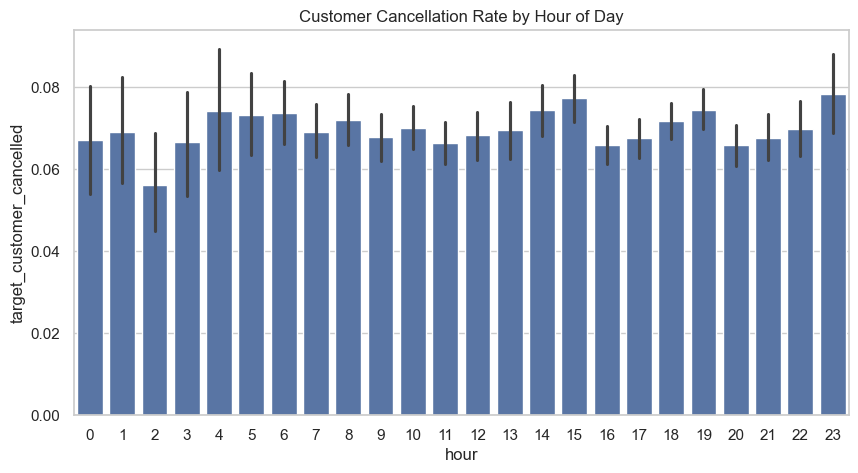

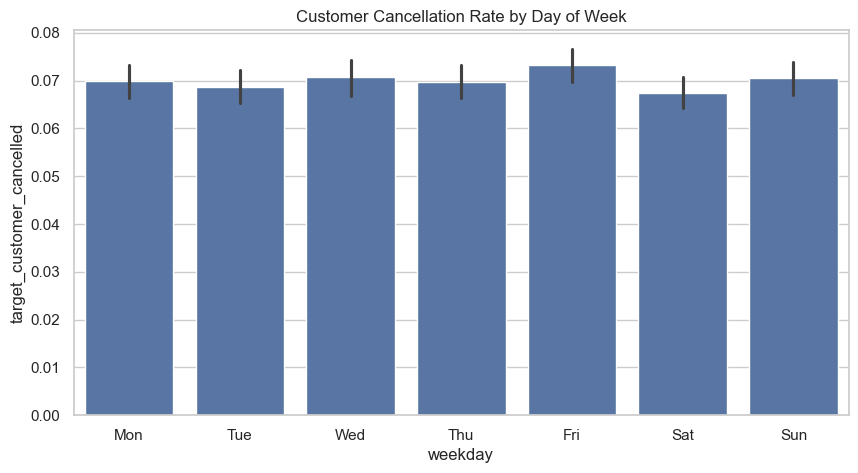

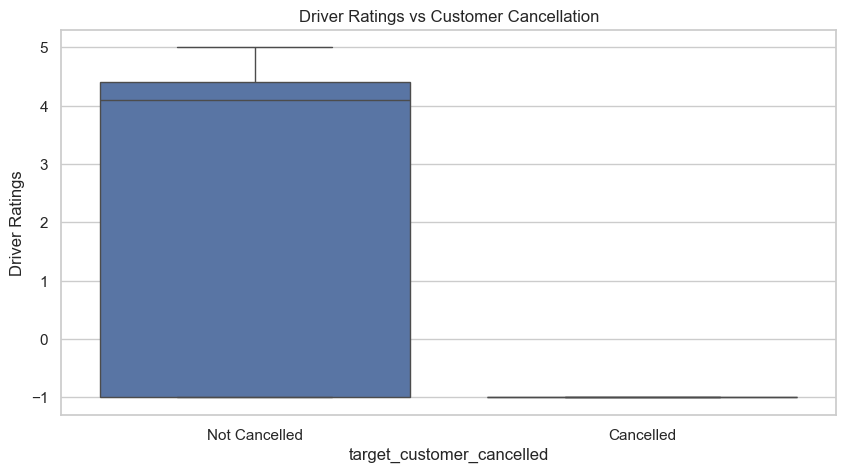

In [141]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set(style="whitegrid")

# 1. Cancellation Rate by Vehicle Type
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Vehicle Type', y='target_customer_cancelled')
plt.title("Customer Cancellation Rate by Vehicle Type")
plt.xticks(rotation=45)
plt.show()

# 2. Cancellation Rate by Hour
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='hour', y='target_customer_cancelled')
plt.title("Customer Cancellation Rate by Hour of Day")
plt.show()

# 3. Cancellation Rate by Day of Week
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='weekday', y='target_customer_cancelled')
plt.title("Customer Cancellation Rate by Day of Week")
plt.xticks(ticks=range(7), labels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.show()

# 4. Driver Rating vs Cancellation
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='target_customer_cancelled', y='Driver Ratings')
plt.title("Driver Ratings vs Customer Cancellation")
plt.xticks([0, 1], ['Not Cancelled', 'Cancelled'])
plt.show()

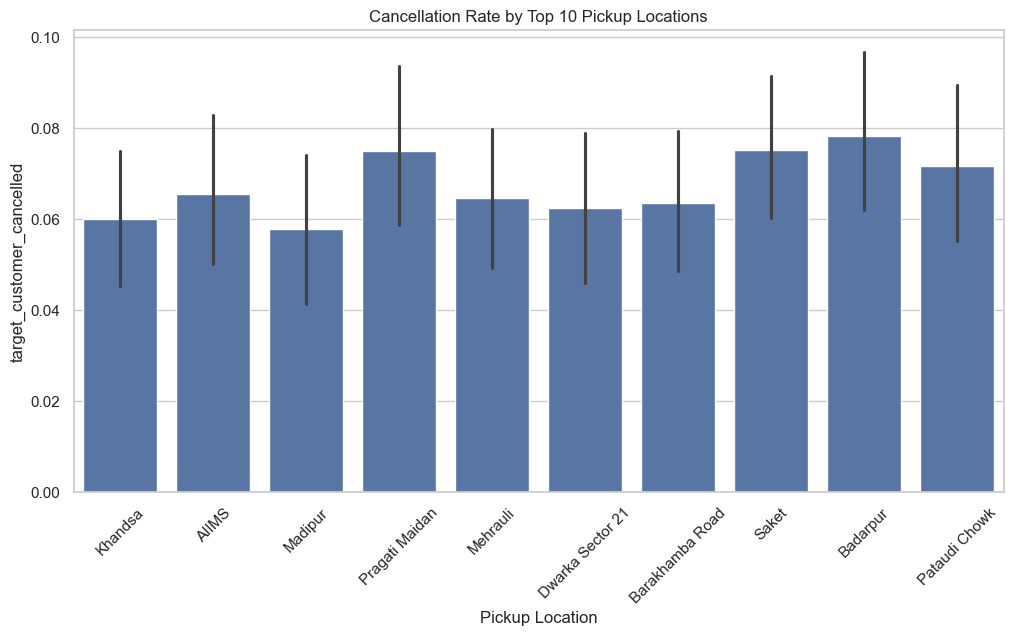

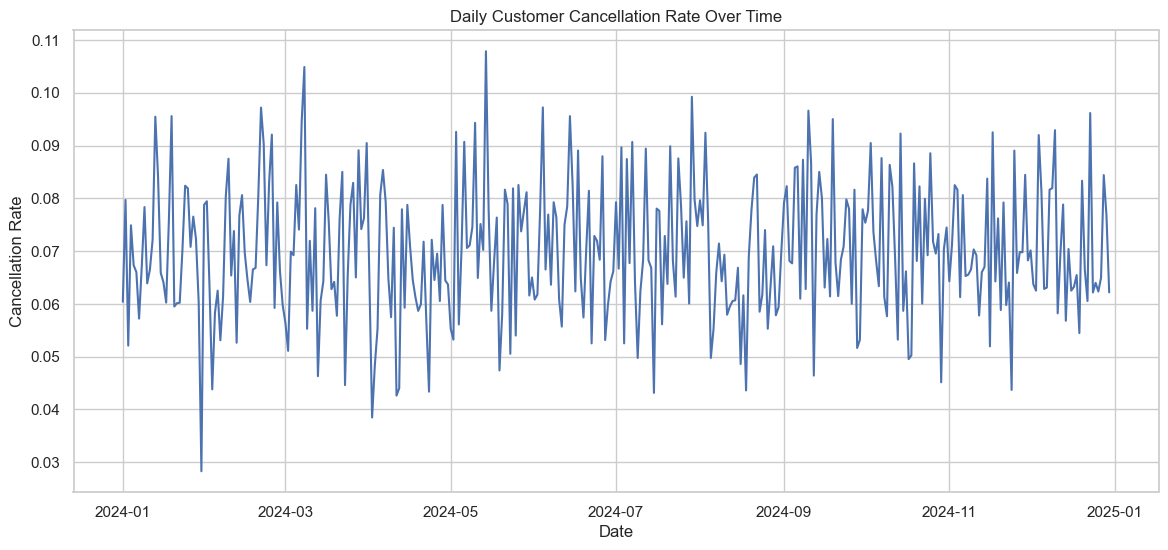

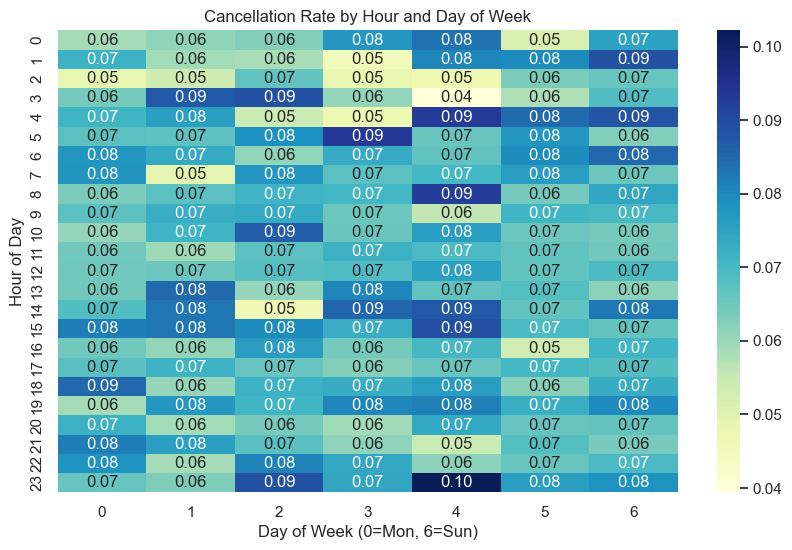

In [142]:
top_pickups = df['Pickup Location'].value_counts().nlargest(10).index
df_top_pickups = df[df['Pickup Location'].isin(top_pickups)]

plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_pickups, x='Pickup Location', y='target_customer_cancelled')
plt.title("Cancellation Rate by Top 10 Pickup Locations")
plt.xticks(rotation=45)
plt.show()

# 2. Trend of Cancellations Over Time (Daily)
df_daily = df.groupby('Date')['target_customer_cancelled'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_daily, x='Date', y='target_customer_cancelled')
plt.title("Daily Customer Cancellation Rate Over Time")
plt.ylabel("Cancellation Rate")
plt.xlabel("Date")
plt.show()

# 3. Optional: Heatmap of Hour vs Day of Week
heatmap_data = df.pivot_table(
    index='hour',
    columns='weekday',
    values='target_customer_cancelled',
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Cancellation Rate by Hour and Day of Week")
plt.ylabel("Hour of Day")
plt.xlabel("Day of Week (0=Mon, 6=Sun)")
plt.show()

### feature engineering

In [147]:
import pandas as pd
import numpy as np

# If dataframe not loaded already
# df = pd.read_excel("cleaned_data.xlsx")

# Clean column names
df.columns = df.columns.str.strip()

print("Available columns:")
print(df.columns.tolist())

# ---------- Find actual column names ----------
vehicle_col = [c for c in df.columns if 'vehicle' in c.lower()][0]
pickup_col  = [c for c in df.columns if 'pickup' in c.lower()][0]
drop_col    = [c for c in df.columns if 'drop' in c.lower()][0]
customer_col= [c for c in df.columns if 'customer id' in c.lower() or 'customer_id' in c.lower()][0]

# 1 Vehicle encoding
df[vehicle_col] = df[vehicle_col].fillna('Unknown')

df = pd.get_dummies(
    df,
    columns=[vehicle_col],
    prefix='vehicle'
)

# 2 Top 10 pickup locations
top_pickups = df[pickup_col].value_counts().nlargest(10).index

df['pickup_encoded'] = df[pickup_col].apply(
    lambda x: x if x in top_pickups else 'Other'
)

df = pd.get_dummies(
    df,
    columns=['pickup_encoded'],
    prefix='pickup'
)

# 3 Top 10 drop locations
top_drops = df[drop_col].value_counts().nlargest(10).index

df['drop_encoded'] = df[drop_col].apply(
    lambda x: x if x in top_drops else 'Other'
)

df = pd.get_dummies(
    df,
    columns=['drop_encoded'],
    prefix='drop'
)

# 4 Customer booking frequency
df['customer_total_bookings'] = (
    df.groupby(customer_col)[customer_col]
      .transform('count')
)

# 5 Drop unnecessary columns
drop_cols = [
'Booking ID','Customer ID',
'Pickup Location','Drop Location',
'Date','Time','datetime'
]

df.drop(columns=drop_cols,
        errors='ignore',
        inplace=True)

# 6 Features + Target
target='target_customer_cancelled'
features=[col for col in df.columns if col != target]

print(f"✅ Total Features: {len(features)}")

Available columns:
['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Payment Method', 'is_cancelled_customer', 'is_cancelled_driver', 'is_incomplete', 'missing_driver_rating', 'missing_customer_rating', 'missing_booking_value', 'missing_payment_method', 'target_customer_cancelled', 'datetime', 'hour', 'day', 'month', 'weekday', 'is_weekend', 'Reason', 'vehicle_Bike', 'vehicle_Go Mini', 'vehicle_Go Sedan', 'vehicle_Premier Sedan', 'vehicle_Uber XL', 'vehicle_eBike', 'pickup_Badarpur', 'pickup_Barakhamba Road', 'pickup_Dwarka Sector 21', 'pickup_Khandsa', 'pickup_Madipur', 'pickup_Mehrauli', 'pickup_Other', 'pickup_Pataudi Chowk', 'pickup_Pragati Maidan', 'pickup_Saket', 'drop_Basai Dhankot', 'drop_Cyber Hub', 'drop_Kalkaji', 'drop_Kashmere Gate ISBT', 'drop_Lajpat Nagar', 'drop_Lok Kalyan Marg', 'drop_Narsinghpur', 'drop_Nehru Place', 'drop_Ot

In [148]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0,1]),   # Fix here
    y=df['target_customer_cancelled']
)

weights = dict(enumerate(class_weights))
print("Class Weights:", weights)

Class Weights: {0: np.float64(0.5376344086021505), 1: np.float64(7.142857142857143)}


In [149]:
import numpy as np

# Combine X and y temporarily
temp_df = df.copy()
temp_df['target'] = df[target]

# Select only numeric columns
numeric_cols = temp_df.select_dtypes(include=[np.number]).columns

# Compute correlation with target
correlations = temp_df[numeric_cols].corr()['target'].sort_values(key=abs, ascending=False)

# Display top correlations (excluding target itself)
print("📌 Top Correlated Features with Target:\n")
print(correlations.drop('target'))

📌 Top Correlated Features with Target:

target_customer_cancelled    1.000000
Customer Rating             -0.347451
Driver Ratings              -0.347266
Avg VTAT                     0.306592
Ride Distance               -0.287715
Booking Value               -0.235359
Avg CTAT                    -0.008883
month                        0.001480
hour                         0.001475
customer_total_bookings      0.001330
day                         -0.000854
weekday                      0.000595
Name: target, dtype: float64


### Logistic regression

In [150]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# Drop target and keep only numeric features
clean_features = df.select_dtypes(include=['number']).columns.drop('target_customer_cancelled')

# Setup X and y
X = df[clean_features]
y = df['target_customer_cancelled']

# Impute missing values
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, stratify=y, random_state=42
)

# Train Logistic Regression
logreg = LogisticRegression(class_weight='balanced', max_iter=1000)
logreg.fit(X_train, y_train)

# Predict
y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)[:, 1]

# Evaluate
print("🎯 ROC AUC Score:", roc_auc_score(y_test, y_prob))
print("\n📋 Classification Report:\n", classification_report(y_test, y_pred, digits=3))

🎯 ROC AUC Score: 0.946808457074586

📋 Classification Report:
               precision    recall  f1-score   support

           0      0.992     0.801     0.886     27900
           1      0.257     0.917     0.402      2100

    accuracy                          0.809     30000
   macro avg      0.625     0.859     0.644     30000
weighted avg      0.941     0.809     0.852     30000



### random forest

In [156]:


from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# ----------------------------
# 1. Remove leakage features safely
# ----------------------------
leaky_features = [
    'Avg VTAT',
    'Ride Distance',
    'Booking Value',
    'Customer Rating',
    'Driver Ratings',
    'Booking Status',
    'Payment Method',
    'missing_booking_value',
    'missing_payment_method',
    'missing_driver_rating',
    'missing_customer_rating',
    'is_cancelled_customer',
    'is_cancelled_driver',
    'is_incomplete'
]

target = 'target_customer_cancelled'

clean_features = [
    col for col in df.columns
    if col not in leaky_features + [target]
]

# ----------------------------
# 2. Prepare X and y
# ----------------------------
X = df[clean_features].copy()
y = df[target]

# Keep only numeric columns (important for RF + median imputer)
X = X.select_dtypes(include=['number', 'bool'])

# Convert bool to int if present
X = X.astype(float)

print("Features used:", X.shape[1])

# ----------------------------
# 3. Impute missing values
# ----------------------------
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# ----------------------------
# 4. Train test split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# ----------------------------
# 5. Random Forest Model
# ----------------------------
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# ----------------------------
# 6. Predictions
# ----------------------------
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

# ----------------------------
# 7. Evaluation
# ----------------------------
print("🎯 ROC AUC:", roc_auc_score(y_test, y_prob))

print("\n📋 Classification Report")
print(classification_report(y_test, y_pred, digits=3))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

# ----------------------------
# 8. Feature Importance
# ----------------------------
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Important Features")
print(importance.head(10))

Features used: 96


0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


🎯 ROC AUC: 0.8626509216589862

📋 Classification Report
              precision    recall  f1-score   support

           0      0.998     0.735     0.847     27900
           1      0.218     0.982     0.357      2100

    accuracy                          0.753     30000
   macro avg      0.608     0.859     0.602     30000
weighted avg      0.944     0.753     0.813     30000


Confusion Matrix
[[20516  7384]
 [   38  2062]]

Top 10 Important Features
                  Feature  Importance
0                Avg CTAT    0.883963
2                     day    0.018325
1                    hour    0.017553
3                   month    0.014243
4                 weekday    0.010155
7        vehicle_Go Sedan    0.002990
6         vehicle_Go Mini    0.002877
10          vehicle_eBike    0.002608
5              is_weekend    0.002599
8   vehicle_Premier Sedan    0.002266


## XG boost and handling

In [154]:
pip install xgboost


6907.66s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 13.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [ ]:

import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# ---------------------------------
# 1. Remove leakage features safely
# ---------------------------------
leaky_features = [
    'Avg VTAT',
    'Ride Distance',
    'Booking Value',
    'Customer Rating',
    'Driver Ratings',
    'Booking Status',
    'Payment Method',
    'missing_booking_value',
    'missing_payment_method',
    'missing_driver_rating',
    'missing_customer_rating',
    'is_cancelled_customer',
    'is_cancelled_driver',
    'is_incomplete'
]

target = 'target_customer_cancelled'

clean_features = [
    c for c in df.columns
    if c not in leaky_features + [target]
]

# ---------------------------------
# 2. Prepare X and y
# ---------------------------------
X = df[clean_features].copy()
y = df[target]

# Keep only numeric columns
X = X.select_dtypes(include=['number','bool']).astype(float)

print("Features used:", X.shape[1])

# ---------------------------------
# 3. Impute missing values
# ---------------------------------
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# ---------------------------------
# 4. Train-test split
# ---------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# ---------------------------------
# 5. Compute imbalance weight
# ---------------------------------
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print("Scale Pos Weight:", scale_pos_weight)

# ---------------------------------
# 6. Train XGBoost
# ---------------------------------
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',

    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,

    scale_pos_weight=scale_pos_weight,

    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# ---------------------------------
# 7. Predictions
# ---------------------------------
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:,1]

# ---------------------------------
# 8. Evaluation
# ---------------------------------
print("🎯 ROC AUC:", roc_auc_score(y_test, y_prob))

print("\n📋 Classification Report")
print(classification_report(y_test, y_pred, digits=3))

print("\nConfusion Matrix")
print(confusion_matrix(y_test,y_pred))

# ---------------------------------
# 9. Feature importance
# ---------------------------------
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nTop 10 Important Features")
print(importance.head(10))

Features used: 96
Scale Pos Weight: 13.285714285714286
🎯 ROC AUC: 0.8647761307390339

📋 Classification Report
              precision    recall  f1-score   support

           0      0.998     0.736     0.847     27900
           1      0.219     0.982     0.358      2100

    accuracy                          0.753     30000
   macro avg      0.608     0.859     0.602     30000
weighted avg      0.944     0.753     0.813     30000


Confusion Matrix
[[20522  7378]
 [   37  2063]]

Top 10 Important Features
                    Feature  Importance
0                  Avg CTAT    0.811276
88         drop_Narsinghpur    0.005532
56          pickup_Badarpur    0.004081
71    pickup_Pragati Maidan    0.003678
81             drop_Kalkaji    0.003365
40        drop_Lajpat Nagar    0.003296
16  pickup_Dwarka Sector 21    0.003086
8     vehicle_Premier Sedan    0.002865
78           drop_Cyber Hub    0.002792
42     drop_Lok Kalyan Marg    0.002714


In [ ]:
cancellation_types = df[df['Booking Status'] != "Completed"]['Booking Status'].value_counts(normalize=True) * 100
cancellation_types

Booking Status
Cancelled by Driver      47.368421
No Driver Found          18.421053
Cancelled by Customer    18.421053
Incomplete               15.789474
Name: proportion, dtype: float64

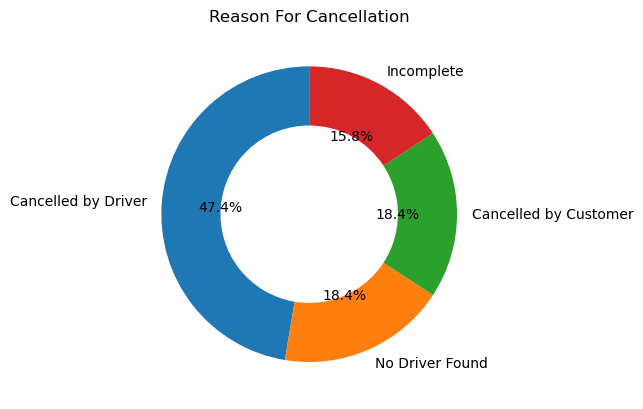

In [ ]:
plt.pie(cancellation_types, labels=cancellation_types.index, autopct="%1.1f%%", startangle=90,
        wedgeprops=dict(width=0.4))
plt.title("Reason For Cancellation")
plt.show()

In [ ]:
Cashh = len(df[df['Payment Method'] == 'Cash'])
Creditt = len(df[df['Payment Method'] != 'Cash'])

cash_rate = Cashh / total * 100
credit_rate = Creditt / total * 100

cash_rate, credit_rate

(16.911333333333335, 83.08866666666667)

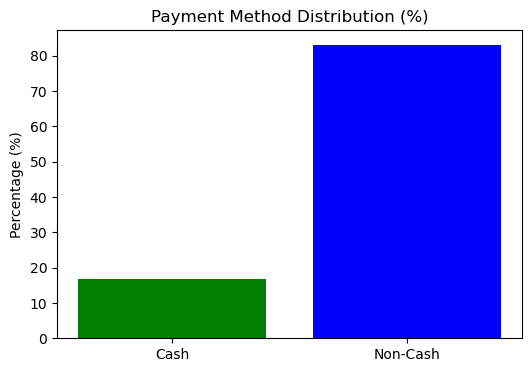

In [ ]:
labels = ['Cash', 'Non-Cash']
values = [cash_rate, credit_rate]

plt.figure(figsize=(6,4))

bars = plt.bar(labels, values, color=['green', 'blue'])

plt.ylabel("Percentage (%)")
plt.title("Payment Method Distribution (%)")

plt.show()

In [ ]:
df['Date+time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

In [ ]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Reason,Date+time
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,-1.0,-1.0,-1.0,-1.00,-1.0,-1.0,NO Payment,No Driver Available,2024-03-23 12:29:38
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,237.0,5.73,-1.0,-1.0,UPI,Vehicle Breakdown,2024-11-29 18:01:39
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,627.0,13.58,4.9,4.9,Debit Card,Everything was fine,2024-08-23 08:56:10
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,416.0,34.02,4.6,5.0,UPI,Everything was fine,2024-10-21 17:17:25
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,737.0,48.21,4.1,4.3,UPI,Everything was fine,2024-09-16 22:08:00


In [ ]:
df['Hour'] = df['Date+time'].dt.hour

In [ ]:
hourly_requests = df.groupby('Hour').size()

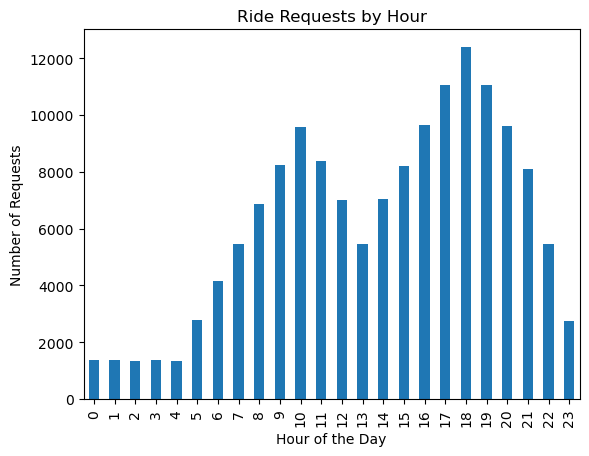

In [ ]:
hourly_requests.plot(kind='bar')

plt.title("Ride Requests by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Requests")

plt.show()

In [ ]:
print("Peak Hour:", hourly_requests.idxmax())
print("Least Busy Hour:", hourly_requests.idxmin())

Peak Hour: 18
Least Busy Hour: 4


In [ ]:
vehicle_orders = df.groupby('Vehicle Type')['Booking ID'].count().sort_values(ascending=False)

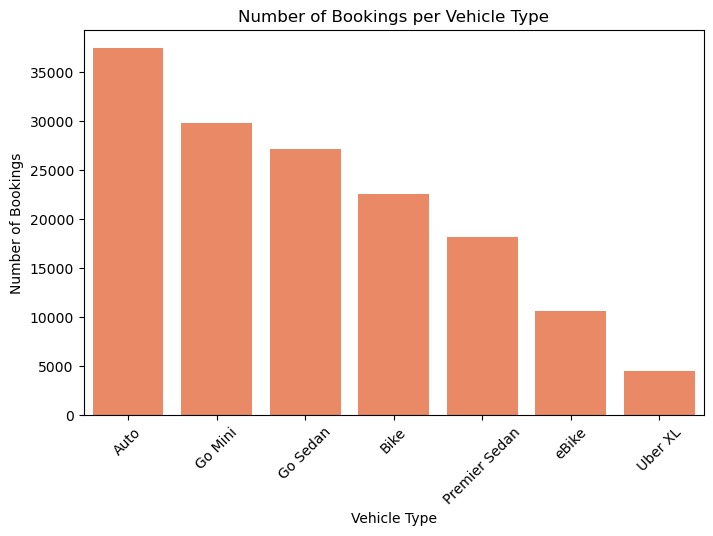

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x=vehicle_orders.index, y=vehicle_orders.values, color='coral')
plt.title("Number of Bookings per Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

In [ ]:
final_df= df.to_excel("Cleaned_Ride_Bookings.xlsx", index=False)

In [ ]:
file_path = os.path.abspath("cleaned_data.xlsx")
df.to_excel(file_path, index=False)

print("File saved at:", file_path)

File saved at: /Users/vibhasharma/python/module/package/cleaned_data.xlsx
